In [ ]:
! pip install numpy pandas matplotlib IPython ISLP 

## 2.4.7. 題目

The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

| Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$ |
|:----:|:-----:|:-----:|:-----:|:-----:|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | $-1$ | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Suppose we wish to use this data set to make a prediction for $Y$ when $X_1=X_2=X_3=0$ using $K$-nearest neighbors.

**(a)** Compute the Euclidean distance between each observation and the test point, $X_1=X_2=X_3=0$.

**(b)** What is our prediction with $K=1$? Why?

**(c)** What is our prediction with $K=3$? Why?

**(d)** If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for $K$ to be large or small? Why?

### (a) 解答

這一小題要計算觀測資料與測試點

$$
\mathbf{x}_0=(0,0,0)
$$

之間的歐氏距離。公式是

$$
d_i=\sqrt{(X_{i1}-0)^2+(X_{i2}-0)^2+(X_{i3}-0)^2}.
$$

定義 obs_n 與 test point 距離為 $d_n$ ，所以代入點可得

$$
\begin{aligned}
d_1 &= \sqrt{0^2+3^2+0^2}=3,\\
d_2 &= \sqrt{2^2+0^2+0^2}=2,\\
d_3 &= \sqrt{0^2+1^2+3^2}=\sqrt{10}\approx 3.162,\\
d_4 &= \sqrt{0^2+1^2+2^2}=\sqrt{5}\approx 2.236,\\
d_5 &= \sqrt{(-1)^2+0^2+1^2}=\sqrt{2}\approx 1.414,\\
d_6 &= \sqrt{1^2+1^2+1^2}=\sqrt{3}\approx 1.732.
\end{aligned}
$$


In [3]:
import numpy as np
import pandas as pd

data = pd.DataFrame({
    "observation": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1,1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

test_point = np.array([0, 0, 0])

# 可以用 data["distance"] = np.linalg.norm(data[["X1", "X2", "X3"]].to_numpy() - test_point, axis=1) 來計算
# np.linalg.norm() 用來計算向量長度，也就是歐氏距離
data["distance"] = np.sqrt((data["X1"] - test_point[0])**2 + (data["X2"] - test_point[1])**2 + (data["X3"] - test_point[2])**2)

print(data["distance"])

0    3.000000
1    2.000000
2    3.162278
3    2.236068
4    1.414214
5    1.732051
Name: distance, dtype: float64


### (b) 解答

當 $K=1$ 時，KNN 只使用距離測試點最近的一筆觀測資料進行分類。

由第 (a) 可知，距離 test point 最近的是第 5 筆觀測值：

$$
(X_1,X_2,X_3)=(-1,0,1),
$$

其距離為

$$
\sqrt{2}
\approx1.414.
$$

由於第 5 筆觀測值的類別為 Green，因此當 $K=1$ 時，測試點的預測類別為

$$
\hat{Y}=\text{Green}.
$$

In [4]:
# idxmin()：找出最小距離所在的資料列索引 
# loc[]：用索引來取出資料列

nearest_neighbor = data.loc[data["distance"].idxmin()]
prediction_k1 = nearest_neighbor["Y"]

print("K = 1 時的預測類別：", prediction_k1)

K = 1 時的預測類別： Green


### (c) 解答

當 $K=3$ 時，KNN 使用距離測試點最近的三筆觀測資料，並以多數決決定測試點的類別。

距離測試點 $(0,0,0)$ 最近的三筆觀測值為：

| 觀測值 | 距離 | 類別 |
|:------:|:-----------------------:|:-----:|
| 5 | $\sqrt{2}\approx1.414$ | Green |
| 6 | $\sqrt{3}\approx1.732$ | Red |
| 2 | $2$ | Red |

在這三個最近鄰中：

- Red 有 2 筆；
- Green 有 1 筆。

由於 Red 占多數，因此當 $K=3$ 時，測試點的預測類別為

$$
\hat{Y}=\text{Red}.
$$

In [5]:
# 給出距離最近三個點
three_nearest_neighbors = data.nsmallest(3, "distance")

# mode()：找出眾數
prediction_k3 = three_nearest_neighbors["Y"].mode().iloc[0]
print("K = 3 時的預測類別：", prediction_k3)

K = 3 時的預測類別： Red


### (d) 解答

較小的 $K$ 只使用測試點附近少數的觀測值進行分類，因此模型具有較高的彈性，可以產生較複雜且彎曲的決策邊界，從而捕捉資料中的局部非線性結構，可以從講義的圖看到 $k$ 比較小比較粗糙。

相反地，當 $K$ 較大時，模型會利用較大範圍內的觀測值進行多數決，使決策邊界變得較平滑。可以從講義中途看到平滑的示意圖，但這可能忽略資料中的局部變化，因而無法準確描述高度非線性的 Bayes 決策邊界。

因此如果 Bayes 決策邊界高度非線性，我覺得最佳的 $K$ 值較小。

## 2.4.8.題目

This exercise relates to the College data set, which can be found in the file `College.csv` on the book website. It contains a number of variables for 777 different universities and colleges in the US. The variables are

- `Private` : Public/private indicator
- `Apps` : Number of applications received
- `Accept` : Number of applicants accepted
- `Enroll` : Number of new students enrolled
- `Top10perc` : New students from top 10% of high school class
- `Top25perc` : New students from top 25% of high school class
- `F.Undergrad` : Number of full-time undergraduates
- `P.Undergrad` : Number of part-time undergraduates
- `Outstate` : Out-of-state tuition
- `Room.Board` : Room and board costs
- `Books` : Estimated book costs
- `Personal` : Estimated personal spending
- `PhD` : Percent of faculty with Ph.D.s
- `Terminal` : Percent of faculty with terminal degree
- `S.F.Ratio` : Student/faculty ratio
- `perc.alumni` : Percent of alumni who donate
- `Expend` : Instructional expenditure per student
- `Grad.Rate` : Graduation rate

Before reading the data into Python, it can be viewed in Excel or a text editor.

**(a)** Use the `pd.read_csv()` function to read the data into Python. Call the loaded data `college`. Make sure that you have the directory set to the correct location for the data.

**(b)** Look at the data used in the notebook by creating and running a new cell with just the code `college` in it. You should notice that the first column is just the name of each university in a column named something like `Unnamed: 0`. We don’t really want `pandas` to treat this as data. However, it may be handy to have these names for later. Try the following commands and similarly look at the resulting data frames:

```python
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'},
                          axis=1)
college3 = college3.set_index('College')
```

This has used the first column in the file as an index for the data frame. This means that `pandas` has given each row a name corresponding to the appropriate university. Now you should see that the first data column is `Private`. Note that the names of the colleges appear on the left of the table. We also introduced a new python object above: a dictionary, which is specified by `(key, value)` pairs. Keep your modified version of the data with the following:

```python
college = college3
```

**(c)** Use the `describe()` method of to produce a numerical summary of the variables in the data set.

**(d)** Use the `pd.plotting.scatter_matrix()` function to produce a scatterplot matrix of the first columns `[Top10perc, Apps, Enroll]`. Recall that you can reference a list `C` of columns of a data frame `A` using `A[C]`.

**(e)** Use the `boxplot()` method of `college` to produce side-by-side boxplots of `Outstate` versus `Private`.

**(f)** Create a new qualitative variable, called `Elite`, by binning the `Top10perc` variable into two groups based on whether or not the proportion of students coming from the top 10% of their high school classes exceeds 50%.

```python
college['Elite'] = pd.cut(college['Top10perc'],
                          [0,0.5,1],
                          labels=['No', 'Yes'])
```

Use the `value_counts()` method of `college['Elite']` to see how many elite universities there are. Finally, use the `boxplot()` method again to produce side-by-side boxplots of `Outstate` versus `Elite`.

**(g)** Use the `plot.hist()` method of `college` to produce some histograms with differing numbers of bins for a few of the quantitative variables. The command `plt.subplots(2, 2)` may be useful: it will divide the plot window into four regions so that four plots can be made simultaneously. By changing the arguments you can divide the screen up in other combinations.

**(h)** Continue exploring the data, and provide a brief summary of what you discover.

### (a) 解答

In [6]:
import pandas as pd

college = pd.read_csv("data/College.csv")
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


### (b) 解答

原始資料的第一欄為 `Unnamed: 0`，其內容是每所大學的名稱，而不是一個用於分析的變數。因此，應將這一欄設定為 DataFrame 的索引。

第一種方法是在使用 `pd.read_csv()` 讀取資料時，透過 `index_col=0` 直接將第一欄指定為索引。
第二種方法是先將第一欄改名為 College，再設為索引

In [7]:
# 方法一：讀取資料時，直接將第一欄設為索引
# index_col=0 直接把 CSV 的第 1 欄當作索引。
college2 = pd.read_csv("data/College.csv", index_col=0)

# 方法二：先將第一欄改名為 College，再設為索引
# axis=1 代表修改欄位名稱
college3 = college.rename(
    {"Unnamed: 0": "College"},
    axis=1
)

# 讓大學取代原先 index 不會被誤認為要分析的變數
college3 = college3.set_index("College")

college = college3

### (c) 解答

使用 `describe()` 方法計算 College 資料集中所有數值變數的有效觀測值數量、平均數、標準差、最小值、四分位數及最大值

In [8]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### (d) 解答

使用 `pd.plotting.scatter_matrix()` 繪製 `Top10perc`、`Apps` 與 `Enroll` 三個變數的散布圖矩陣，以觀察各變數的分布及其兩兩之間的關係。

從散布圖可以看出，`Apps` 與 `Enroll` 之間具有明顯的正向關係：收到申請人數較多的學校，通常也有較多的新生入學。`Top10perc` 與另外兩個變數之間的關係則較為分散，線性關係沒有 `Apps` 與 `Enroll` 之間明顯。此外，`Apps` 和 `Enroll` 的分布皆呈現右偏，表示大多數學校的申請及入學人數較少，但少數大型學校的人數非常高。

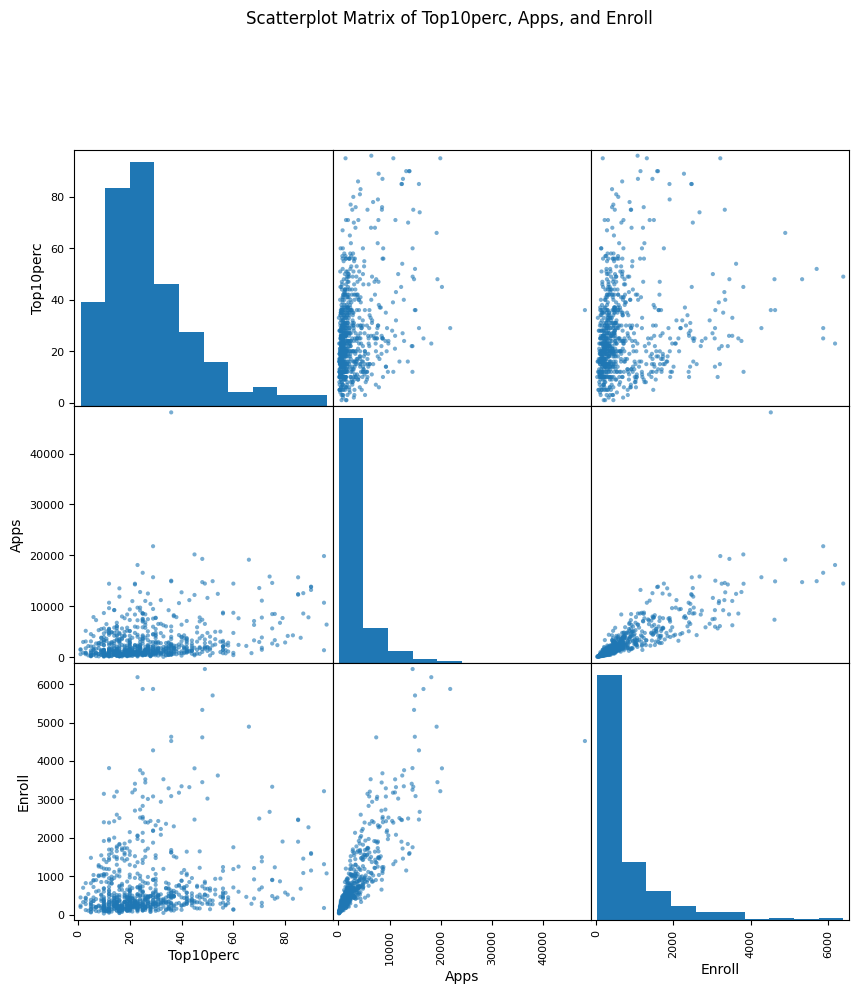

In [9]:
import matplotlib.pyplot as plt

columns = ["Top10perc", "Apps", "Enroll"]

# scatter_matrix 會一次畫出所有變數兩兩之間的散布圖，自己對自己沒意義所以戶畫直方圖表示自己分布情況
pd.plotting.scatter_matrix(
    college[columns],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.6
)

plt.suptitle(
    "Scatterplot Matrix of Top10perc, Apps, and Enroll",
    y=1.02
)

plt.show()

### (e) 解答

使用並列箱型圖比較公立學校與私立學校的外州學生學費分布，其中 `Private = Yes` 代表私立學校，`Private = No` 代表公立學校。

從箱型圖可以看出，私立學校的外州學生學費中位數明顯高於公立學校，且私立學校的學費分布整體位於較高的位置。雖然兩組學費仍有部分重疊，但學校是否為私立與外州學生學費之間存在明顯關聯；整體而言，私立學校的外州學生學費較高。

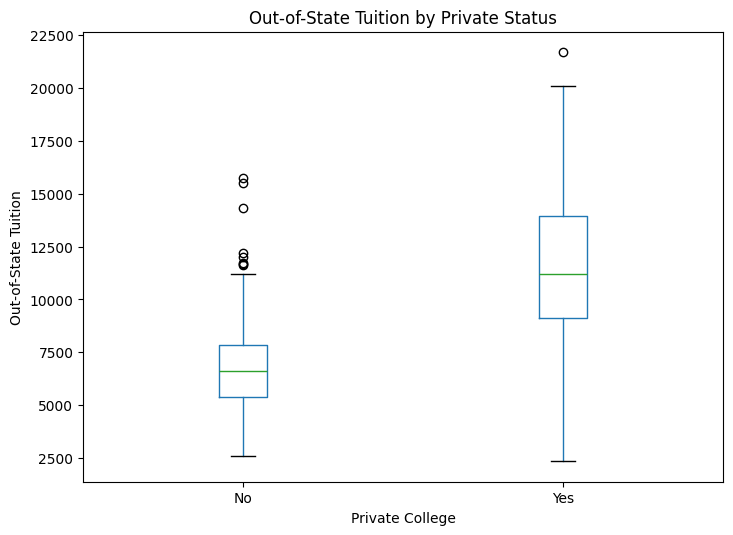

In [10]:
college.boxplot(
    column="Outstate",
    by="Private",
    figsize=(8, 6),
    grid=False
)

plt.title("Out-of-State Tuition by Private Status")
plt.suptitle("")
plt.xlabel("Private College")
plt.ylabel("Out-of-State Tuition")
plt.show()

### (f) 解答

根據 `Top10perc` 建立新的質性變數 `Elite`。若一所學校的新生中，來自高中班級前 10% 的比例超過 50%，則將該學校分類為 `Elite = Yes`；否則分類為 `Elite = No`。

結果顯示，資料集中共有 78 所 Elite 學校及 699 所非 Elite 學校。從並列箱型圖可以看出，Elite 學校的外州學生學費中位數明顯高於非 Elite 學校，且整體學費分布也位於較高的位置。因此，Elite 學校通常具有較高的外州學生學費。

In [11]:
# 確認最大值以及最低值方便後續切割，最小 1% 最大 96%，所以除以100轉成range[0,1]
college["Top10perc"].min(), college["Top10perc"].max()
college["Top10perc"] = college["Top10perc"] / 100

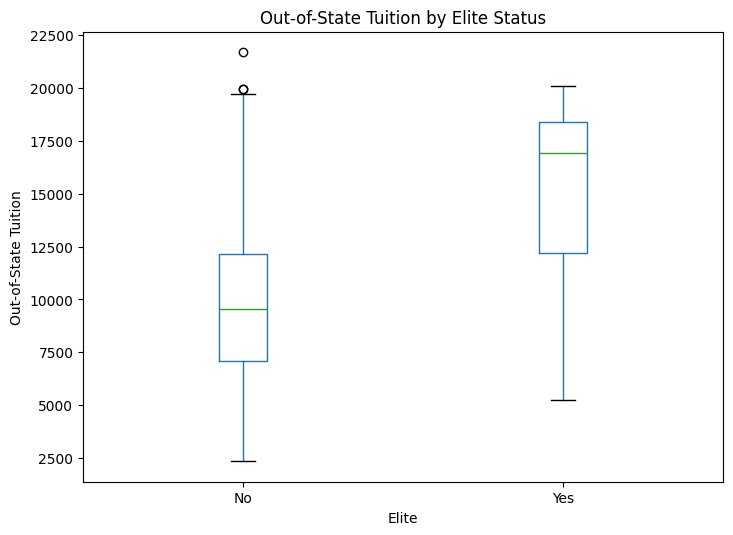

In [12]:
college["Elite"] = pd.cut(
    college["Top10perc"],
    bins=[0, 0.5, 1],
    labels=["No", "Yes"]
)

# 計算兩組學校數量
college["Elite"].value_counts()

college.boxplot(
    column="Outstate",
    by="Elite",
    figsize=(8, 6),
    grid=False
)

plt.title("Out-of-State Tuition by Elite Status")
plt.suptitle("")
plt.xlabel("Elite")
plt.ylabel("Out-of-State Tuition")
plt.show()

### (g) 解答

選擇 `Apps` 與 `Outstate` 兩個數值變數，並分別使用 10 個及30 個 bins 繪製直方圖，以觀察 bins 數量對資料分布呈現方式的影響。
使用較少的 bins 時，直方圖較平滑，但可能隱藏部分分布細節；使用較多的 bins 時，可以觀察到更細微的局部分布特徵，但圖形也會變得較不平滑。

`Apps` 的分布明顯右偏，表示大部分學校收到的申請數相對較少，但少數學校收到非常大量的申請。`Outstate` 的分布範圍較廣，顯示不同學校的外州學生學費存在明顯差異，且`Outstate` 在 1.5-2 萬區間較多的 bin 更能清楚展示其中的分布。

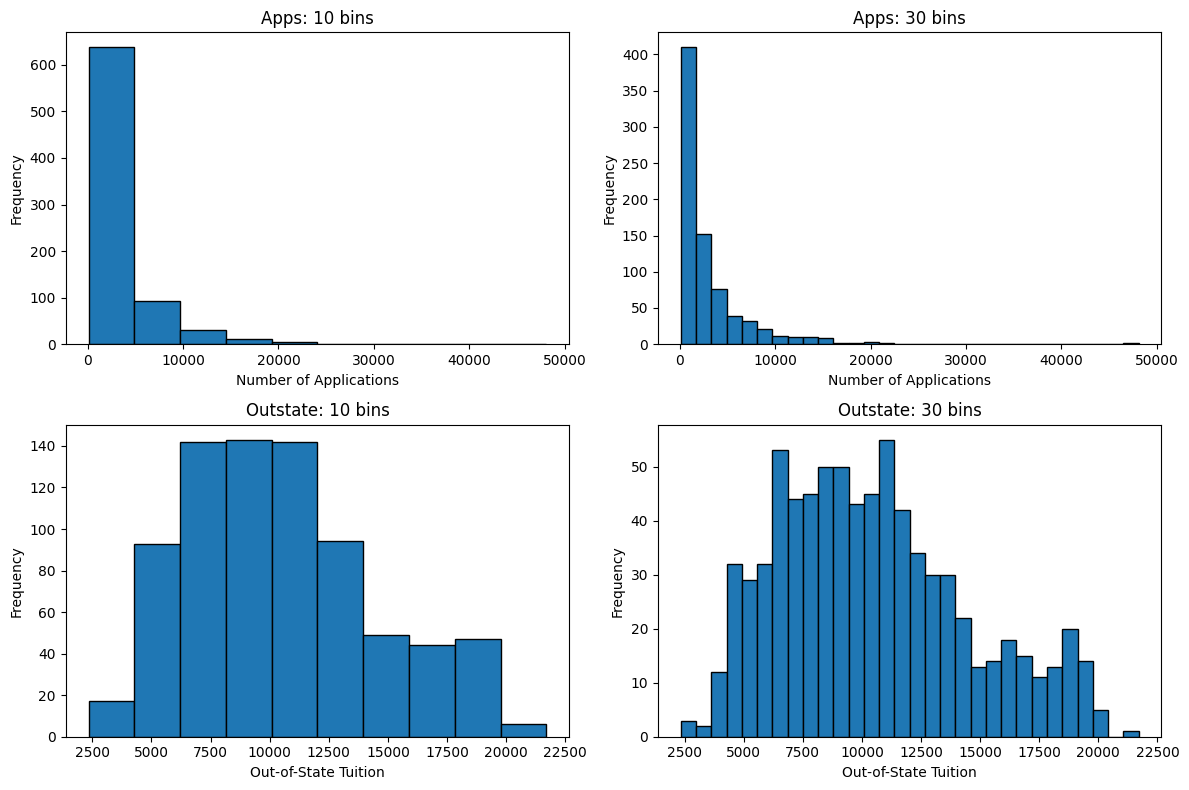

In [13]:
# plt.subplots(2, 2)：建立 \(2\times2\) 的四個畫圖區域。
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Apps：10 個 bins
college.plot.hist(
    y="Apps",
    bins=10,            # bins=10：將資料範圍切成 10 組
    ax=axes[0, 0],
    edgecolor="black",
    legend=False
)
axes[0, 0].set_title("Apps: 10 bins")
axes[0, 0].set_xlabel("Number of Applications")
axes[0, 0].set_ylabel("Frequency")

# Apps：30 個 bins
college.plot.hist(
    y="Apps",
    bins=30,
    ax=axes[0, 1],
    edgecolor="black",
    legend=False
)
axes[0, 1].set_title("Apps: 30 bins")
axes[0, 1].set_xlabel("Number of Applications")
axes[0, 1].set_ylabel("Frequency")

# Outstate：10 個 bins
college.plot.hist(
    y="Outstate",
    bins=10,
    ax=axes[1, 0],
    edgecolor="black",
    legend=False
)
axes[1, 0].set_title("Outstate: 10 bins")
axes[1, 0].set_xlabel("Out-of-State Tuition")
axes[1, 0].set_ylabel("Frequency")

# Outstate：30 個 bins
college.plot.hist(
    y="Outstate",
    bins=30,
    ax=axes[1, 1],
    edgecolor="black",
    legend=False
)
axes[1, 1].set_title("Outstate: 30 bins")
axes[1, 1].set_xlabel("Out-of-State Tuition")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### (h) 解答

最終變數選擇學費、每生教育支出、入學生學業背景及學生／教師比，
探討它們與學校資源及畢業率的關係。選這些變數作為分析原因是因為從第一個 BLOCK 的變數相關係數矩陣可以看到那些具有相關性，再結合常識選擇最後分析對象，接著搭配散布圖做分析，並依公私立區分進行比較。

#### 1. 學費、教育支出與畢業率

`Outstate` 與 `Grad.Rate` 的 Pearson 相關係數約為 **0.571**，
表示外州學費較高的學校，通常也具有較高的畢業率。
分別觀察公立與私立學校，相關係數約為 **0.389** 與 **0.517**，
顯示此正向關係在兩種類型內仍然存在。

`Expend` 與 `Grad.Rate` 的相關係數約為 **0.390**，
顯示每生教育支出與畢業率呈正相關，但關聯程度有限，
不能只憑教育支出解釋各校畢業率的差異。

#### 2. 入學生學業背景與畢業率

`Top10perc` 與 `Grad.Rate` 的相關係數約為 **0.495**。
高中成績位於前 10% 的新生比例較高時，學校的畢業率通常也較高。
這提示我們，在討論學費、教育支出與畢業率的關係時，
也應考慮入學生學業背景的差異。

#### 3. 教育支出、學費與教學資源

`Expend` 與 `S.F.Ratio` 的相關係數約為 **−0.584**，
表示每生教育支出較高的學校，通常具有較低的學生／教師比。
不過，學生／教師比並不等同於實際班級人數，
因此不能直接將此結果解讀為班級規模較小。

`Expend` 與 `Outstate` 的相關係數約為 **0.673**，
顯示較高的外州學費通常伴隨較高的每生教育支出。
但這個關係本身無法說明學費收入的實際用途。

#### 4. 異常畢業率

資料中 Cazenovia College 的 `Grad.Rate` 為 **118%**，
超出一般百分比的合理範圍，因此將其標記並進行敏感度分析。
排除該筆資料後，外州學費與畢業率的相關係數由 **0.571**
變為約 **0.576**，此正向關係並未因排除該筆資料而明顯改變。

但是公私立類型、入學生背景及其他因素都可能與這些變數同時相關，因此不能據此推論學費跟畢業率有因果關係。

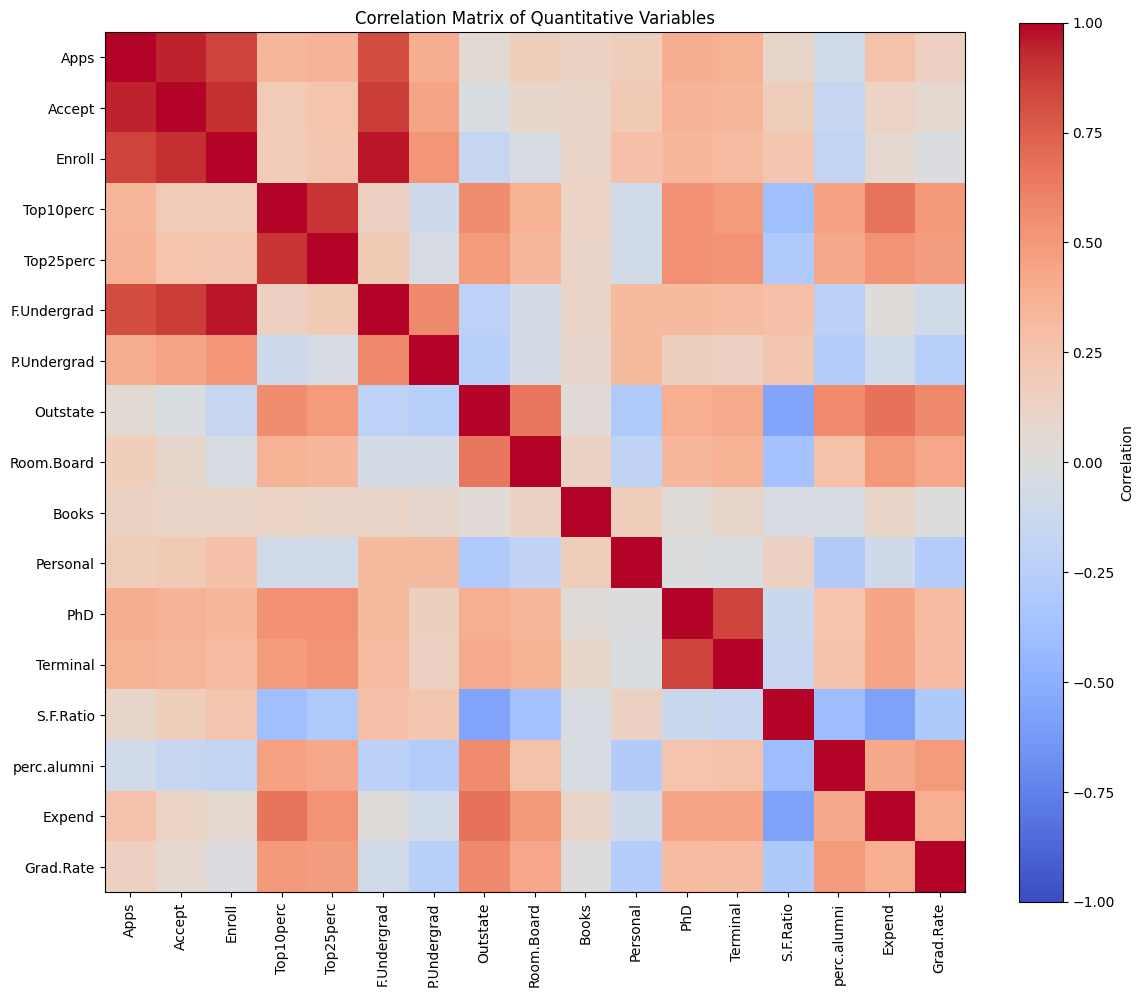

In [14]:
numeric_college = college.select_dtypes(include="number")
correlation_matrix = numeric_college.corr()

fig, ax = plt.subplots(figsize=(12, 10))

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)
ax.set_yticklabels(correlation_matrix.columns)

plt.colorbar(image, ax=ax, label="Correlation")
plt.title("Correlation Matrix of Quantitative Variables")
plt.tight_layout()
plt.show()

,Grad.Rate
Cazenovia College,118


,X,Y,Pearson,Spearman
0,Outstate,Grad.Rate,0.571,0.589
1,Expend,Grad.Rate,0.390,0.427
2,Top10perc,Grad.Rate,0.495,0.482
3,Expend,S.F.Ratio,-0.584,-0.658
4,Expend,Outstate,0.673,0.744


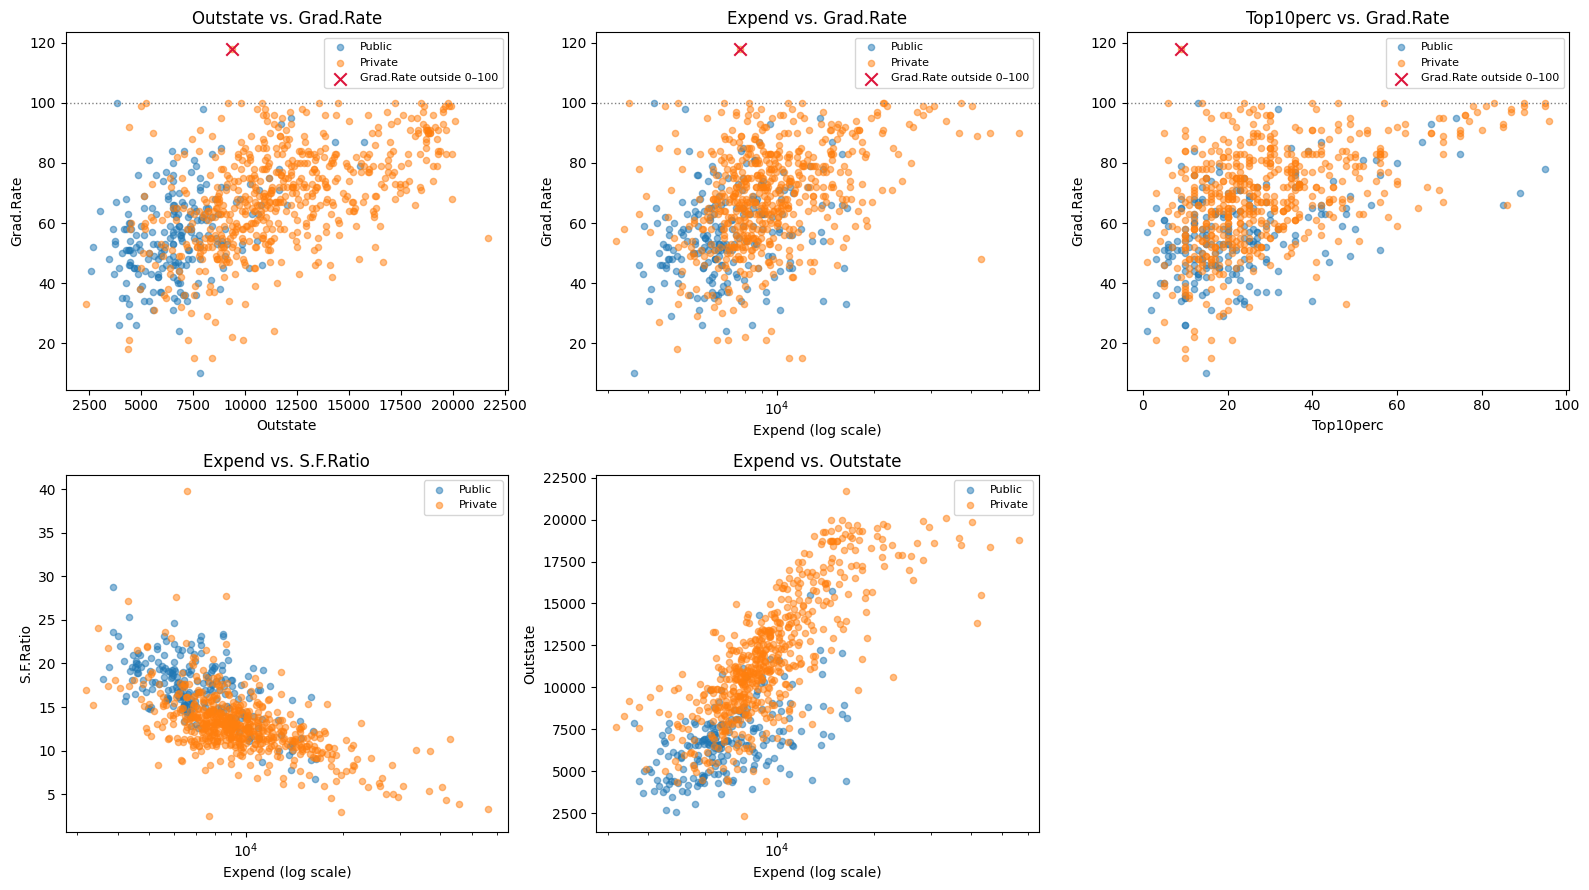

In [15]:
from IPython.display import display

# 使用獨立資料，保留 Top10perc 原本的百分數單位
explore = pd.read_csv("data/College.csv", index_col=0)

# 檢查畢業率是否超出合理範圍，保留原始資料並標記，最大值為118顯然超過100
invalid_grad = ~explore["Grad.Rate"].between(0, 100)
display(explore.loc[invalid_grad, ["Grad.Rate"]])

pairs = [
    ("Outstate", "Grad.Rate"),
    ("Expend", "Grad.Rate"),
    ("Top10perc", "Grad.Rate"),
    ("Expend", "S.F.Ratio"),
    ("Expend", "Outstate"),
]

# 原始資料的相關係數，方便對照各組關係
correlations = pd.DataFrame([
    {
        "X": x,
        "Y": y,
        "Pearson": explore[x].corr(explore[y]),
        "Spearman": explore[x].corr(explore[y], method="spearman"),
    }
    for x, y in pairs
])

display(correlations.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors = {"No": "tab:blue", "Yes": "tab:orange"}
labels = {"No": "Public", "Yes": "Private"}

for ax, (x, y) in zip(axes.flat, pairs):
    for private in ["No", "Yes"]:
        group = explore.loc[explore["Private"] == private]

        ax.scatter(
            group[x], group[y],
            color=colors[private],
            label=labels[private],
            alpha=0.5,
            s=20,
        )

    # 每生支出右偏，使用對數座標方便觀察
    if x == "Expend":
        ax.set_xscale("log")

    # 明確標出不合理的畢業率，不默默刪除
    if y == "Grad.Rate":
        flagged = explore.loc[invalid_grad]
        ax.scatter(
            flagged[x], flagged[y],
            color="crimson",
            marker="x",
            s=80,
            label="Grad.Rate outside 0–100",
        )
        ax.axhline(100, color="gray", linestyle=":", linewidth=1)

    ax.set_xlabel(f"{x} (log scale)" if x == "Expend" else x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs. {y}")
    ax.legend(fontsize=8)

axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

In [16]:
# 分別計算公立、私立學校內的 Pearson 相關係數
within_type = pd.DataFrame([
    {
        "X": x,
        "Y": y,
        "Public": explore.loc[explore["Private"] == "No", x].corr(
            explore.loc[explore["Private"] == "No", y]
        ),
        "Private": explore.loc[explore["Private"] == "Yes", x].corr(
            explore.loc[explore["Private"] == "Yes", y]
        ),
    }
    for x, y in pairs
])

display(within_type.round(3))

# 敏感度分析：僅在涉及畢業率時排除異常紀錄
valid_grad = explore.loc[~invalid_grad]

sensitivity = pd.DataFrame([
    {
        "X": x,
        "Pearson: all records": explore[x].corr(explore["Grad.Rate"]),
        "Pearson: valid graduation rates": valid_grad[x].corr(
            valid_grad["Grad.Rate"]
        ),
    }
    for x in ["Outstate", "Expend", "Top10perc"]
])

display(sensitivity.round(3))

,X,Y,Public,Private
0,Outstate,Grad.Rate,0.389,0.517
1,Expend,Grad.Rate,0.231,0.358
2,Top10perc,Grad.Rate,0.445,0.482
3,Expend,S.F.Ratio,-0.627,-0.549
4,Expend,Outstate,0.514,0.674


,X,Pearson: all records,Pearson: valid graduation rates
0,Outstate,0.571,0.576
1,Expend,0.390,0.394
2,Top10perc,0.495,0.503


## 2.4.9.題目

This exercise involves the Auto data set studied in the lab. Make sure that the missing values have been removed from the data.

**(a)** Which of the predictors are quantitative, and which are qualitative?

**(b)** What is the range of each quantitative predictor? You can answer this using the `min()` and `max()` methods in `numpy`.

**(c)** What is the mean and standard deviation of each quantitative predictor?

**(d)** Now remove the 10th through 85th observations. What is the range, mean, and standard deviation of each predictor in the subset of the data that remains?

**(e)** Using the full data set, investigate the predictors graphically, using scatterplots or other tools of your choice. Create some plots highlighting the relationships among the predictors. Comment on your findings.

**(f)** Suppose that we wish to predict gas mileage (`mpg`) on the basis of the other variables. Do your plots suggest that any of the other variables might be useful in predicting `mpg`? Justify your answer.

### preprocessing

導入資料以及做缺失值刪除處理

In [17]:
auto = pd.read_csv("data/Auto.csv", na_values=["?"])

# 移除含缺失值的觀測值，原本有397筆資料只有392筆完整
n_before = len(auto)
auto = auto.dropna().copy()

print(f"移除 {n_before - len(auto)} 筆含缺失值的資料")
print(f"剩餘 {len(auto)} 筆資料")

移除 5 筆含缺失值的資料
剩餘 392 筆資料


### (a) 解答

**量化變數（Quantitative ）**：表示數量或大小，數值之間的差距具有實際意義，可以進行平均值、標準差等計算。

**質性變數（Qualitative）**：表示類別或名稱，用來區分不同群體。

Auto 資料集的變數可分為：

| 類型 | 變數 | 說明 |
|---|---|---|
| 量化變數 | `mpg` | 每加侖燃料可行駛的英里數 |
| 量化變數 | `displacement` | 引擎排氣量 |
| 量化變數 | `horsepower` | 馬力 |
| 量化變數 | `weight` | 車重 |
| 量化變數 | `acceleration` | 加速所需時間 |
| 量化變數（離散） | `cylinders` | 汽缸數，是具有數量意義的計數 |
| 量化變數（離散） | `year` | 車款年份，年份差距具有意義 |
| 質性變數 | `origin` | 產地類別，數字只是類別代碼 |
| 質性變數 | `name` | 車款名稱，主要用於識別車款 |

### (b) 解答

結果如下：

| 變數 | 範圍 |
|:---|:---|
| `mpg` | $[9.0,46.6]$ |
| `cylinders` | $[3,8]$ |
| `displacement` | $[68,455]$ |
| `horsepower` | $[46,230]$ |
| `weight` | $[1613,5140]$ |
| `acceleration` | $[8.0,24.8]$ |
| `year` | $[70,82]$ |


In [18]:
quantitative_variables = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "year"
]

minimum = np.min(auto[quantitative_variables], axis=0)
maximum = np.max(auto[quantitative_variables], axis=0)

range_table = pd.DataFrame({
    "Minimum": minimum,
    "Maximum": maximum,
    "Range_length": maximum - minimum
})

display(range_table)

,Minimum,Maximum,Range_length
mpg,9.0,46.6,37.6
cylinders,3.0,8.0,5.0
displacement,68.0,455.0,387.0
horsepower,46.0,230.0,184.0
weight,1613.0,5140.0,3527.0
acceleration,8.0,24.8,16.8
year,70.0,82.0,12.0


### (c)解答

`quantitative predictor` 的 `mean` 跟 `standard deviation` 結果如下：

| Predictor | Mean | Standard Deviation |
|---|---:|---:|
| mpg | 23.446 | 7.805 |
| cylinders | 5.472 | 1.706 |
| displacement | 194.412 | 104.644 |
| horsepower | 104.469 | 38.491 |
| weight | 2977.584 | 849.403 |
| acceleration | 15.541 | 2.759 |
| year | 75.980 | 3.684 |

In [19]:
quantitative_variables = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "year"
]

summary_9c = pd.DataFrame({
    "Mean": auto[quantitative_variables].mean(),
    "Standard Deviation": auto[quantitative_variables].std()
})

summary_9c

,Mean,Standard Deviation
mpg,23.445918,7.805007
cylinders,5.471939,1.705783
displacement,194.411990,104.644004
horsepower,104.469388,38.491160
weight,2977.584184,849.402560
acceleration,15.541327,2.758864
year,75.979592,3.683737


### (d)解答

刪除第 10 筆至第 85 筆觀測值後，`quantitative_variable` 的 `range`, `mean`, `standard deviation` 如下：

| Predictor | Range | Mean | Standard Deviation |
|---|---|---:|---:|
| mpg | 11.0–46.6 | 24.404 | 7.867 |
| cylinders | 3–8 | 5.373 | 1.654 |
| displacement | 68.0–455.0 | 187.241 | 99.678 |
| horsepower | 46.0–230.0 | 100.722 | 35.709 |
| weight | 1649–4997 | 2935.972 | 811.300 |
| acceleration | 8.5–24.8 | 15.727 | 2.694 |
| year | 70–82 | 77.146 | 3.106 |

In [20]:
# 刪除第 10 筆至第 85 筆觀測值
auto_subset = auto.drop(auto.index[9:85])

# 確認剩餘資料筆數
print("Number of remaining observations:", auto_subset.shape[0])

# 計算統計量
summary_9d = pd.DataFrame({
    "Minimum": auto_subset[quantitative_variables].min(),
    "Maximum": auto_subset[quantitative_variables].max(),
    "Mean": auto_subset[quantitative_variables].mean(),
    "Standard Deviation": auto_subset[quantitative_variables].std()
})

summary_9d.round(3)

Number of remaining observations: 316


,Minimum,Maximum,Mean,Standard Deviation
mpg,11.0,46.6,24.404,7.867
cylinders,3.0,8.0,5.373,1.654
displacement,68.0,455.0,187.241,99.678
horsepower,46.0,230.0,100.722,35.709
weight,1649.0,4997.0,2935.972,811.300
acceleration,8.5,24.8,15.727,2.694
year,70.0,82.0,77.146,3.106


### (e)解答


從散佈圖矩陣以及兩變數之間的相關係數矩陣可以觀察到下列關係：

- `mpg` 與 `cylinders`、`displacement`、`horsepower` 和 `weight` 呈現明顯的負相關。也就是說，汽缸數越多、排氣量越大、馬力越高或車身越重，汽車的燃油效率通常越低。
- `cylinders`、`displacement`、`horsepower` 和 `weight` 彼此呈現明顯的正相關。汽缸數較多的汽車通常具有較大的排氣量、較高的馬力及較重的車身。
- `year` 與 `mpg` 呈現正相關，表示年份較新的汽車通常具有較好的燃油效率。
- `acceleration` 整體關係比引擎規格與車重之間的關係弱，但仍存在中度相關。
- 從散佈圖可以看出，`mpg` 與 `weight`、`displacement` 和 `horsepower` 之間的關係具有一定程度的彎曲趨勢，因此這些關係可能不是完全線性的。

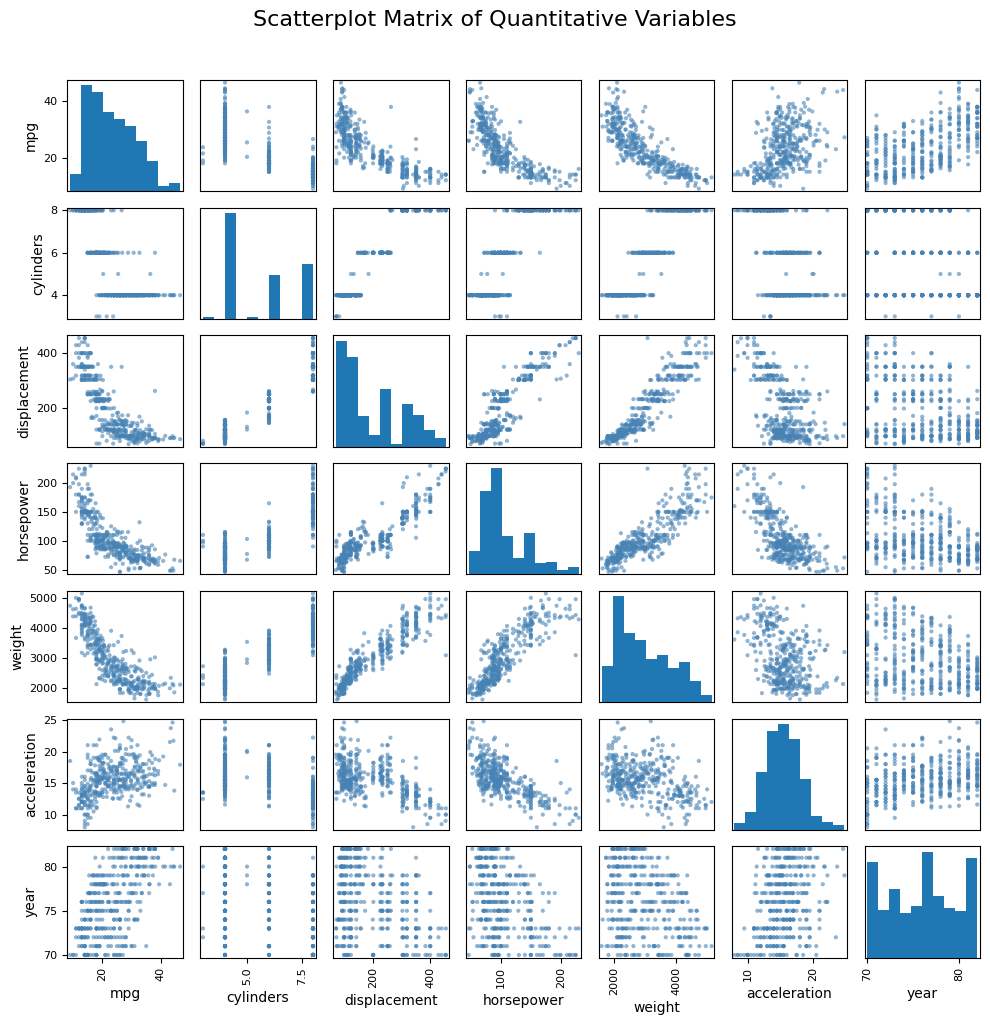

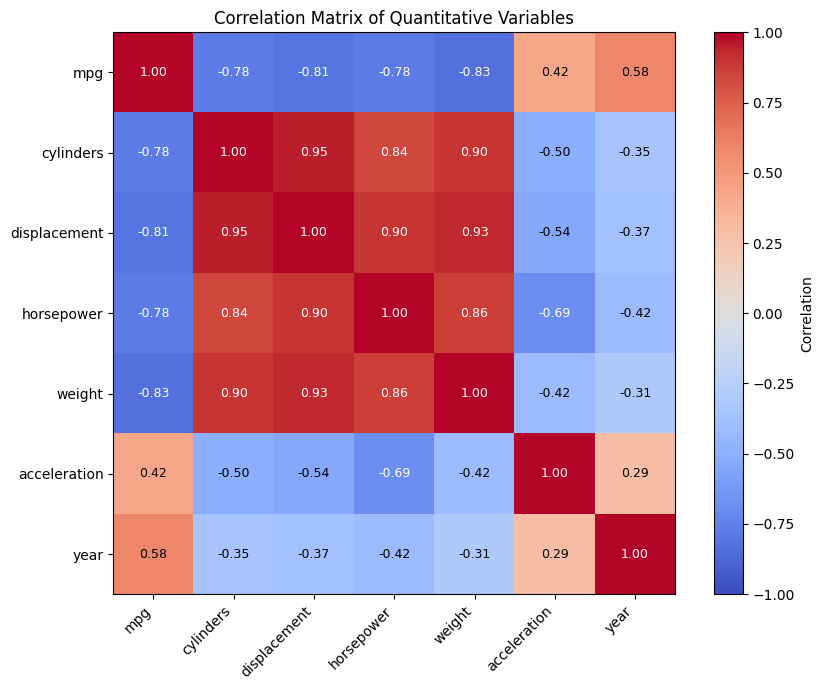

In [21]:
axes = pd.plotting.scatter_matrix(
    auto[quantitative_variables],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.6,
    color="steelblue"
)

# 從其中一個子圖取得完整 Figure
fig = axes[0, 0].get_figure()

fig.suptitle(
    "Scatterplot Matrix of Quantitative Variables",
    fontsize=16,
    y=1.02
)
fig.tight_layout()

display(fig)

# 防止 Notebook 再自動顯示一次
plt.close(fig)


# 計算 quantitative variables 的相關係數矩陣
correlation_matrix = auto[quantitative_variables].corr()

# 建立圖形與座標軸
fig, ax = plt.subplots(figsize=(9, 7))

# 繪製相關係數矩陣
image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# 加入顏色刻度
fig.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

# 設定座標軸刻度與變數名稱
ax.set_xticks(range(len(quantitative_variables)))
ax.set_xticklabels(
    quantitative_variables,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(quantitative_variables)))
ax.set_yticklabels(quantitative_variables)

# 在每個格子中標示相關係數
for i in range(len(quantitative_variables)):
    for j in range(len(quantitative_variables)):
        correlation = correlation_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{correlation:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if abs(correlation) > 0.6 else "black"
        )

# 設定標題並調整版面
ax.set_title("Correlation Matrix of Quantitative Variables")
fig.tight_layout()

# 顯示圖片
display(fig)

# 避免 Jupyter 重複顯示圖片
plt.close(fig)

### (f) 解答

我覺得 plot 多個變數有助於預測 `mpg`

其中，`weight`、`displacement`、`horsepower` 和 `cylinders` 與 `mpg` 呈現明顯的負相關，相關係數分別約為 `-0.83`、`-0.81`、`-0.78` 和 `-0.78`。因此，車身越重、排氣量越大、馬力越高或汽缸數越多，`mpg` 通常越低。這些變數可能是預測 `mpg` 時的重要變數，其中 `weight` 與 `mpg` 的線性關係最強。

`year` 與 `mpg` 的相關係數約為 `0.58`，呈現中度正相關，表示年份較新的汽車通常具有較高的燃油效率。因此，`year` 也可能是有用的預測變數。

`acceleration` 與 `mpg` 的相關係數約為 `0.42`，兩者具有一定程度的正相關，因此也可能提供預測資訊，但其關係比上述變數弱。

且散佈圖顯示 `mpg` 與 `weight`、`displacement` 和 `horsepower` 之間可能存在非線性關係。因此，在建立預測模型時，除了線性項之外，也可以考慮加入非線性項。

最後依據兩變數之間的相關係數矩陣可以看出 `cylinders`、`displacement`、`horsepower` 和 `weight` 彼此高度相關，因此這些變數可能包含重複的資訊。結論就是 `weight`、`displacement`、`horsepower`、`cylinders`、`year` 和 `acceleration` 都可能有助於預測 `mpg`。

## 2.4.10.題目

This exercise involves the Boston housing data set.

**(a)** To begin, load in the Boston data set, which is part of the `ISLP` library.

**(b)** How many rows are in this data set? How many columns? What do the rows and columns represent?

**(c)** Make some pairwise scatterplots of the predictors (columns) in this data set. Describe your findings.

**(d)** Are any of the predictors associated with per capita crime rate? If so, explain the relationship.

**(e)** Do any of the suburbs of Boston appear to have particularly high crime rates? Tax rates? Pupil-teacher ratios? Comment on the range of each predictor.

**(f)** How many of the suburbs in this data set bound the Charles river?

**(g)** What is the median pupil-teacher ratio among the towns in this data set?

**(h)** Which suburb of Boston has lowest median value of owner-occupied homes? What are the values of the other predictors for that suburb, and how do those values compare to the overall ranges for those predictors? Comment on your findings.

**(i)** In this data set, how many of the suburbs average more than seven rooms per dwelling? More than eight rooms per dwelling? Comment on the suburbs that average more than eight rooms per dwelling.

### (a) 解答

下載 `ISLP` 了

In [22]:
from ISLP import load_data
Boston = load_data("Boston")

# 顯示前五筆資料
display(Boston.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### (b) 解答

Boston housing data 共有 506 列與 13 欄。

`row` 代表 Boston 地區的一個郊區或 census tract，共有 506 個觀測單位。

`column` 代表該地區的一項特徵，例如人均犯罪率、住宅房間數、房產稅率、學生與教師比例，以及房屋價格中位數等。其中 `medv` 表示自有住宅價格中位數，單位為 1,000 美元；其餘欄位則描述各地區的社會、住宅、環境及交通特徵。

In [23]:
print("資料維度：", Boston.shape)
print("資料筆數：", Boston.shape[0])
print("變數數量：", Boston.shape[1])

display(Boston.head())

資料維度： (506, 13)
資料筆數： 506
變數數量： 13


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### (c) 解答

從散佈圖矩陣與所選擇的 pairwise scatterplots，可以看到：

- `lstat` 與 `medv` 呈現明顯的負相關。社經地位較低人口所占比例越高，房屋價格中位數通常越低。散佈圖呈現彎曲的趨勢，因此兩者的關係可能不是完全線性的。

- `lstat` 與 `rm` 呈現明顯的負相關。這表示社經地位較低人口比例較高的地區，住宅的平均房間數通常較少。

- `dis` 與 `nox` 呈現明顯的負相關。距離 Boston 就業中心越遠的地區，其氮氧化物濃度通常越低，而且兩者之間可能存在非線性關係。

- `age` 與 `dis` 呈現明顯的負相關。1940 年以前建造的自有住宅比例越高，該地區與 Boston 就業中心的加權平均距離通常越短。

- `rm` 與 `medv` 呈現明顯的正相關。住宅的平均房間數越多，房屋價格中位數通常越高。此外，部分觀測值的 `medv` 集中在 50，表示這個變數可能存在資料上限。

- `rad` 與 `tax` 呈現明顯的正相關。接近放射狀公路的便利程度指標越高，房產稅率通常也越高。由於 `rad` 是離散型變數，因此散佈圖呈現數條垂直的帶狀分布。


此外，完整的散佈圖矩陣顯示部分變數的分布並不對稱。例如，`crim` 的分布明顯右偏，並存在少數犯罪率特別高的觀測值。整體來說 Boston housing data 中的住宅條件、社會經濟狀況、交通便利程度、環境品質與房屋價格之間存在多組明顯關聯。

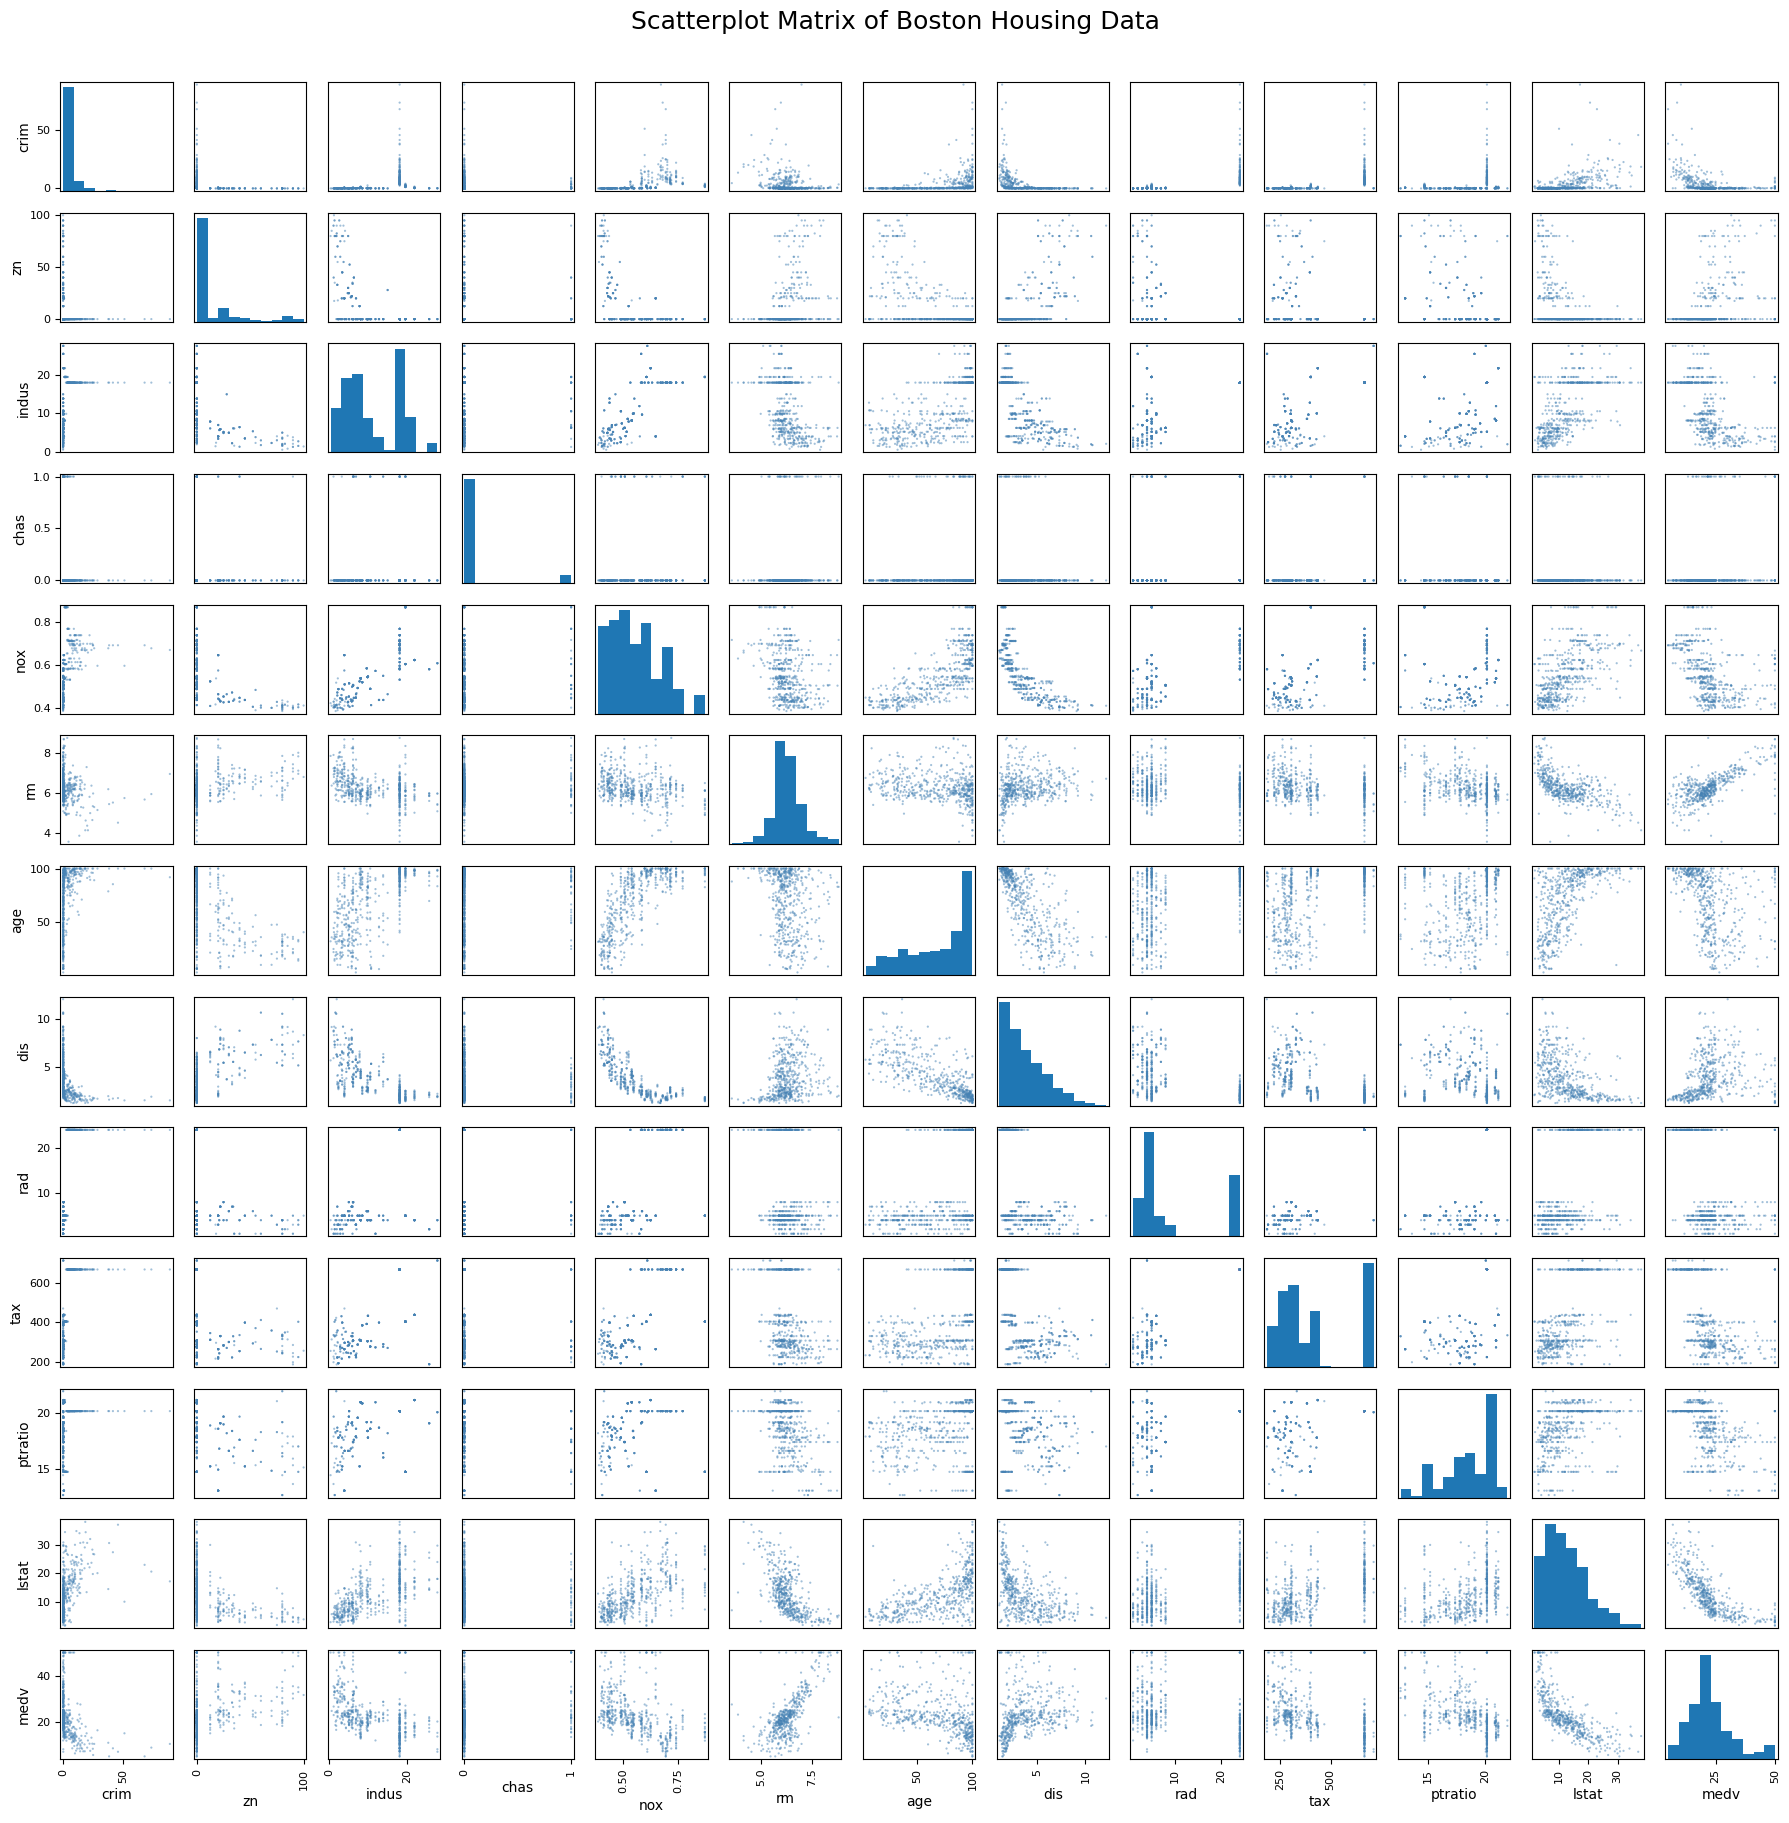

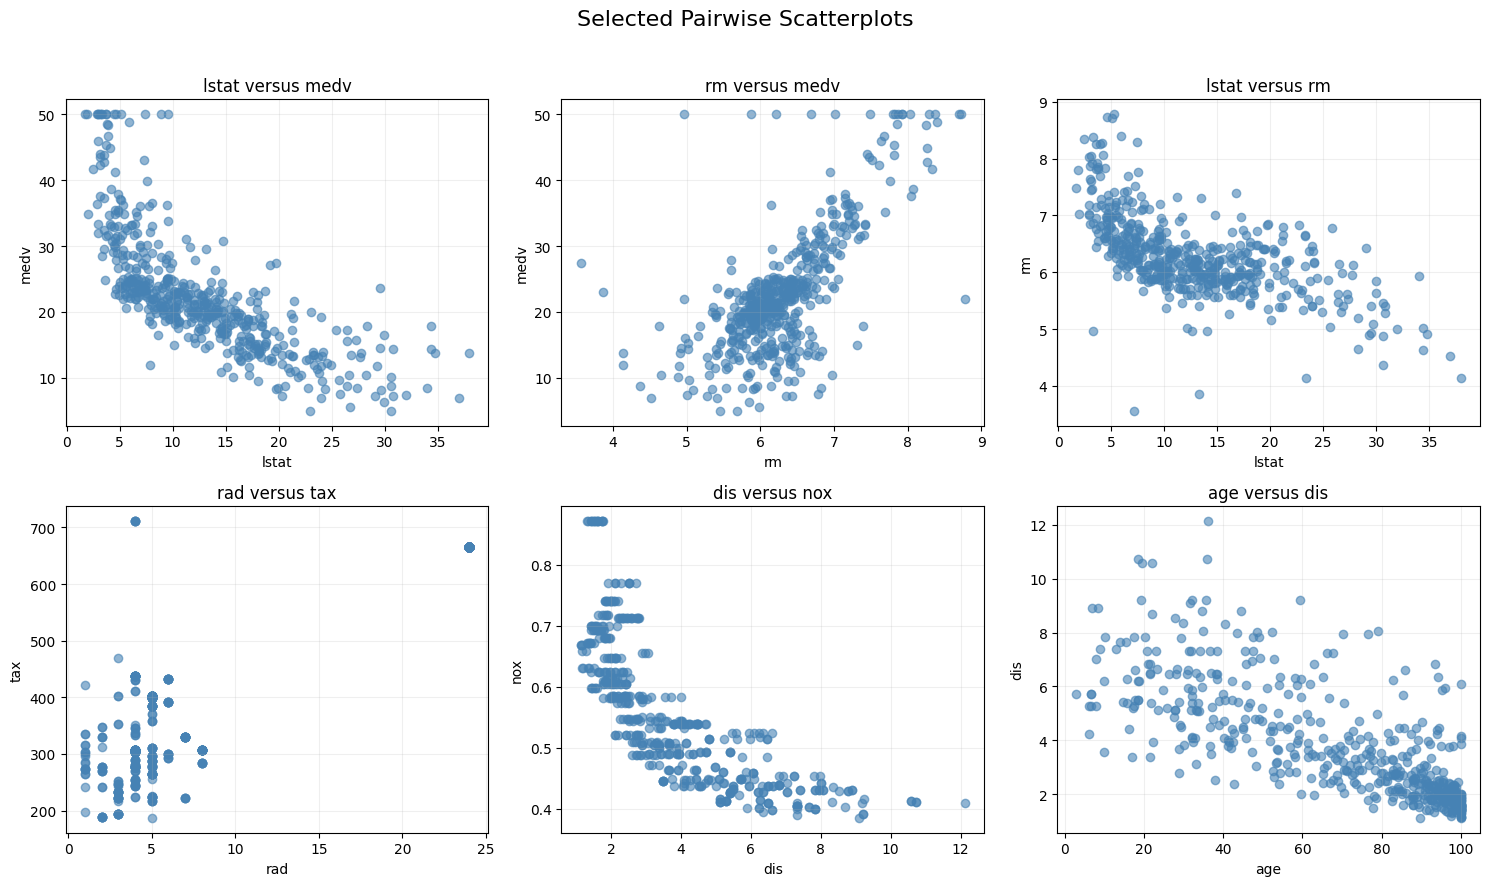

In [28]:
# 繪製所有變數的散佈圖矩陣
axes = pd.plotting.scatter_matrix(
    Boston,
    figsize=(18, 18),
    diagonal="hist",
    alpha=0.5,
    color="steelblue",
    s=10
)

# 取得完整圖形
fig = axes[0, 0].get_figure()

fig.suptitle(
    "Scatterplot Matrix of Boston Housing Data",
    fontsize=18,
    y=1.01
)

fig.tight_layout()

display(fig)
plt.close(fig)

variable_pairs = [
    ("lstat", "medv"),
    ("rm", "medv"),
    ("lstat", "rm"),
    ("rad", "tax"),
    ("dis", "nox"),
    ("age", "dis")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (x_variable, y_variable) in zip(
    axes.flatten(),
    variable_pairs
):
    ax.scatter(
        Boston[x_variable],
        Boston[y_variable],
        alpha=0.6,
        color="steelblue"
    )

    ax.set_xlabel(x_variable)
    ax.set_ylabel(y_variable)
    ax.set_title(f"{x_variable} versus {y_variable}")
    ax.grid(alpha=0.2)

fig.suptitle(
    "Selected Pairwise Scatterplots",
    fontsize=16
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
display(fig)
plt.close(fig)


### (d) 解答

部分變數與人均犯罪率 `crim` 存在明顯關聯。

`rad` 和 `tax` 與 `crim` 的相關係數分別約為 `0.63` 和 `0.58`，呈現較明顯的正相關。這表示放射狀公路便利程度指標或房產稅率較高的地區，通常也具有較高的犯罪率。

`lstat`、`nox` 和 `indus` 與 `crim` 的相關係數分別約為 `0.46`、`0.42` 和 `0.41`，呈現中度正相關。社經地位較低人口比例、氮氧化物濃度及非零售商業用地比例較高的地區，犯罪率通常也比較高。

另一方面，`medv` 和 `dis` 與 `crim` 的相關係數分別約為 `-0.39` 和 `-0.38`。房屋價格較高或距離 Boston 就業中心較遠的地區，犯罪率通常較低。

`chas` 與 `crim` 的相關係數接近 0，表示是否鄰近 Charles River 與犯罪率之間沒有明顯的線性關係。

不過，`crim` 的分布高度右偏，並存在一些極端值，因此相關係數可能受到高犯罪率地區影響。此外，相關性只表示變數之間存在關聯，不能直接解釋為因果關係。

,Correlation with crim
rad,0.626
tax,0.583
lstat,0.456
nox,0.421
indus,0.407
medv,-0.388
dis,-0.380
age,0.353
ptratio,0.290
rm,-0.219


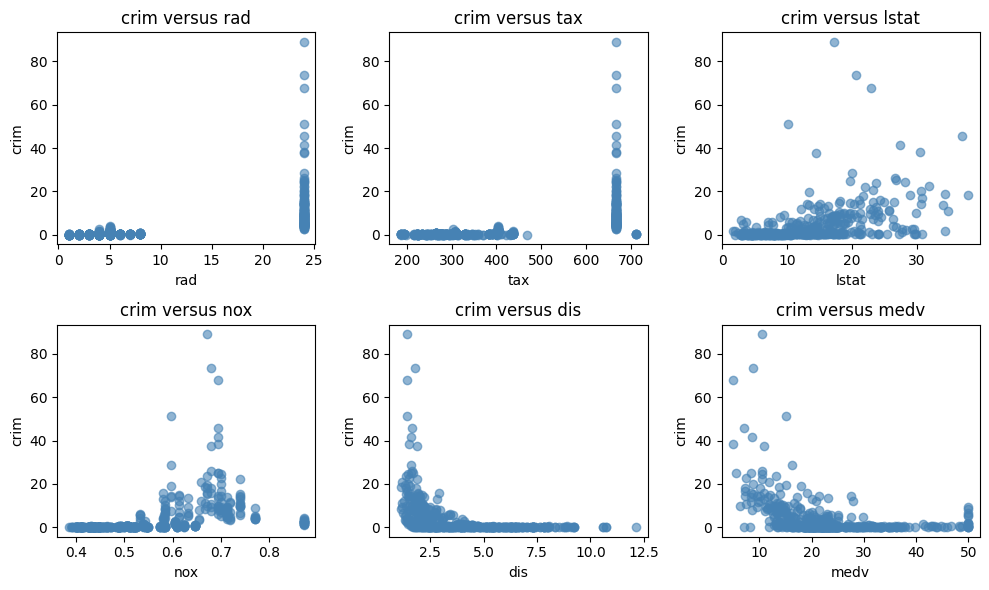

In [25]:
# 計算其他變數與 crim 的相關係數
crime_correlations = (
    Boston.corr(numeric_only=True)["crim"]
    .drop("crim")
)

# 按照相關程度的絕對值排序
crime_correlations = crime_correlations.loc[
    crime_correlations.abs().sort_values(ascending=False).index
]

display(
    crime_correlations
    .to_frame("Correlation with crim")
    .round(3)
)

variables = ["rad", "tax", "lstat", "nox", "dis", "medv"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, variable in zip(axes.flatten(), variables):
    ax.scatter(
        Boston[variable],
        Boston["crim"],
        alpha=0.6,
        color="steelblue"
    )
    ax.set_xlabel(variable)
    ax.set_ylabel("crim")
    ax.set_title(f"crim versus {variable}")

fig.tight_layout()
display(fig)
plt.close(fig)


### (e) 解答

資料中確實存在犯罪率特別高的地區。`crim` 的最小值約為 `0.0063`，最大值約為 `88.9762`，但第三四分位數只有約 `3.6771`。這表示大部分地區的犯罪率不高，只有少數地區具有極高的犯罪率，因此 `crim` 的分布明顯右偏且存在離群值。

`tax` 的範圍為 `187` 至 `711`。部分地區的房產稅率相當高，而且許多高稅率地區集中在 `666` 附近。不過，`tax` 的高值不像 `crim` 的最大值那麼孤立。

`ptratio` 的範圍為 `12.6` 至 `22.0`。部分地區具有較高的學生與教師比例，但整體範圍比 `crim` 和 `tax` 集中，沒有像犯罪率一樣明顯的極端離群值。


| 變數 | 最小值 | 最大值 |
|---|---:|---:|
| `crim` | 0.0063 | 88.9762 |
| `zn` | 0.0 | 100.0 |
| `indus` | 0.46 | 27.74 |
| `chas` | 0 | 1 |
| `nox` | 0.385 | 0.871 |
| `rm` | 3.561 | 8.780 |
| `age` | 2.9 | 100.0 |
| `dis` | 1.1296 | 12.1265 |
| `rad` | 1 | 24 |
| `tax` | 187 | 711 |
| `ptratio` | 12.6 | 22.0 |
| `lstat` | 1.73 | 37.97 |
| `medv` | 5.0 | 50.0 |

其中，`chas` 是 binary variable，因此只會取 `0` 或 `1`。此外，不同變數的單位不同，因此不能只根據數值範圍的大小比較各變數的變異程度。

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.614,8.602,0.006,0.082,0.257,3.677,88.976
tax,506.0,408.237,168.537,187.000,279.000,330.000,666.000,711.000
ptratio,506.0,18.456,2.165,12.600,17.400,19.050,20.200,22.000


crim 最高的五個地區：


,crim,tax,ptratio
380,88.9762,666,20.2
418,73.5341,666,20.2
405,67.9208,666,20.2
410,51.1358,666,20.2
414,45.7461,666,20.2


tax 最高的五個地區：


,crim,tax,ptratio
488,0.15086,711,20.1
489,0.18337,711,20.1
490,0.20746,711,20.1
491,0.10574,711,20.1
492,0.11132,711,20.1


ptratio 最高的五個地區：


,crim,tax,ptratio
354,0.04301,334,22.0
355,0.10659,334,22.0
127,0.25915,437,21.2
128,0.32543,437,21.2
129,0.88125,437,21.2


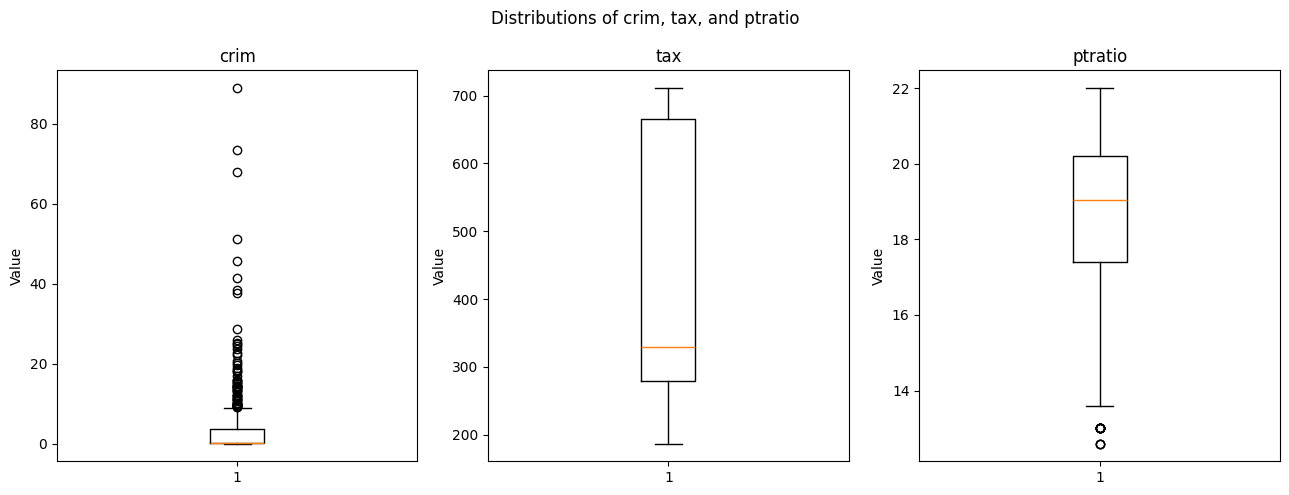

,Minimum,Maximum,Range
crim,0.0063,88.9762,88.9699
zn,0.0000,100.0000,100.0000
indus,0.4600,27.7400,27.2800
chas,0.0000,1.0000,1.0000
nox,0.3850,0.8710,0.4860
rm,3.5610,8.7800,5.2190
age,2.9000,100.0000,97.1000
dis,1.1296,12.1265,10.9969
rad,1.0000,24.0000,23.0000
tax,187.0000,711.0000,524.0000


In [26]:
# 查看 crim、tax 與 ptratio 的分布摘要
display(
    Boston[["crim", "tax", "ptratio"]]
    .describe()
    .T
    .round(3)
)

# 顯示各變數最高的五個地區
for variable in ["crim", "tax", "ptratio"]:
    print(f"{variable} 最高的五個地區：")
    display(
        Boston.nlargest(5, variable)[
            ["crim", "tax", "ptratio"]
        ]
    )
    
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, variable in zip(axes, ["crim", "tax", "ptratio"]):
    ax.boxplot(Boston[variable])
    ax.set_title(variable)
    ax.set_ylabel("Value")

fig.suptitle("Distributions of crim, tax, and ptratio")
fig.tight_layout()

display(fig)
plt.close(fig)

range_table = pd.DataFrame({
    "Minimum": Boston.min(),
    "Maximum": Boston.max(),
    "Range": Boston.max() - Boston.min()
})

display(range_table.round(4))

### (f) 解答

`chas` 是表示該地區是否鄰近 Charles River 的 binary variable，其中 `chas = 1` 表示鄰近 Charles River，`chas = 0` 表示不鄰近。

資料中共有 **35 個地區**鄰近 Charles River。

In [31]:
# 因為 chas 變數是二元變數，計算總和即可得知鄰近 Charles River 的地區數量
number_bounding_charles = int(Boston["chas"].sum())

print(
    "鄰近 Charles River 的地區數量：",
    number_bounding_charles
)

鄰近 Charles River 的地區數量： 35


### (g) 解答

Boston housing data 中，學生—教師比率 `ptratio` 的中位數為 **19.05**。

In [36]:
median_ptratio = Boston["ptratio"].median()

print("學生—教師比率的中位數：", median_ptratio)

學生—教師比率的中位數： 19.05


### (h) 解答

`medv` 的最低值為 5，代表自有住宅價格中位數為 5,000 美元。資料中共有兩個地區並列最低，即第 399 筆與第 406 筆觀測。

這兩個地區具有一些相似特徵：

- `crim` 分別為 38.3518 和 67.9208，相較於整體範圍 0.0063 至 88.9762，兩者的犯罪率都相當高。
- `zn` 均為 0，位於整體範圍的最低值。
- `indus` 均為 18.10，在整體範圍 0.46 至 27.74 中屬於較高的數值。
- `nox` 均為 0.693，相較於整體範圍 0.385 至 0.871，氮氧化物濃度偏高。
- `age` 均為 100，等於整體最大值，表示住宅全部建於 1940 年以前。
- `dis` 分別為 1.4896 和 1.4254，接近整體最小值 1.1296，表示這些地區距離 Boston 就業中心較近。
- `rad` 均為 24，等於整體最大值。
- `tax` 均為 666，接近整體最大值 711。
- `ptratio` 均為 20.2，接近整體最大值 22。
- `lstat` 分別為 30.59 和 22.98，在整體範圍 1.73 至 37.97 中屬於較高的數值。

整體而言，房屋價格最低的兩個地區具有高犯罪率、較高的空氣污染、老舊住宅比例高、房產稅率高、學生—教師比率高，以及社經地位較低人口比例偏高等特徵。這些特徵可能與較低的房屋價格有關，但僅根據這些描述性結果不能直接判定因果關係。

In [40]:
# 找出最低的 medv
minimum_medv = Boston["medv"].min()

# 找出所有 medv 等於最低值的地區
lowest_medv_suburbs = Boston[
    Boston["medv"] == minimum_medv
]

print("最低的 medv：", minimum_medv)
# Index 輸出成 ([398, 405], dtype="int64")，tolist() 轉換成 [398, 405]
print("觀測資料編號：", (lowest_medv_suburbs.index + 1).tolist())

display(lowest_medv_suburbs)

predictors = Boston.columns.drop("medv")

comparison = pd.DataFrame({
    "Overall Minimum": Boston[predictors].min(),
    "Observation 399": lowest_medv_suburbs.iloc[0][predictors],
    "Observation 406": lowest_medv_suburbs.iloc[1][predictors],
    "Overall Maximum": Boston[predictors].max()
})

display(comparison.round(4))

最低的 medv： 5.0
觀測資料編號： [399, 406]


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
398,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,30.59,5.0
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,22.98,5.0


,Overall Minimum,Observation 399,Observation 406,Overall Maximum
crim,0.0063,38.3518,67.9208,88.9762
zn,0.0000,0.0000,0.0000,100.0000
indus,0.4600,18.1000,18.1000,27.7400
chas,0.0000,0.0000,0.0000,1.0000
nox,0.3850,0.6930,0.6930,0.8710
rm,3.5610,5.4530,5.6830,8.7800
age,2.9000,100.0000,100.0000,100.0000
dis,1.1296,1.4896,1.4254,12.1265
rad,1.0000,24.0000,24.0000,24.0000
tax,187.0000,666.0000,666.0000,711.0000


### (i) 解答

資料集中共有 **64 個**郊區的平均住宅房間數 `rm` 大於 7，共有 **13 個**郊區的平均住宅房間數 `rm` 大於 8。

觀察平均房間數大於 8 的 13 個郊區，可以發現：

- 這些郊區的 `rm` 介於約 8.03 到 8.78 之間。
- `medv` 的平均值約為 44.2，高於整體資料集的平均值，且其中許多郊區的 `medv` 達到資料中的上限 50。
- `lstat` 整體偏低，介於約 2.47 到 7.44，表示這些郊區中低社經地位人口的比例通常較低。
- `crim` 相較於整體資料範圍通常較低，其最大值約為 3.47，遠低於完整資料集的最大值約 88.98。
- 不過，這些郊區的其他特徵仍存在差異。例如 `medv` 並非全部都很高，其中最低值約為 21.9。

整體而言，平均房間數大於 8 的郊區通常具有較高的房價中位數、較低的 `lstat` 與相對較低的犯罪率，但並非每個郊區都完全符合這些特徵。

In [43]:
# 篩選平均房間數大於 7 與大於 8 的郊區
more_than_7_rooms = Boston[Boston["rm"] > 7]
more_than_8_rooms = Boston[Boston["rm"] > 8]

print("平均房間數大於 7 的郊區數量：", len(more_than_7_rooms))
print("平均房間數大於 8 的郊區數量：", len(more_than_8_rooms))

# 顯示平均房間數大於 8 的郊區
display("平均房間數大於 8 的郊區表格：", more_than_8_rooms)

# 顯示這些郊區各變數的敘述統計量
display("平均房間數大於 8 的郊區敘述統計量：", more_than_8_rooms.describe().T.round(2))

平均房間數大於 7 的郊區數量： 64
平均房間數大於 8 的郊區數量： 13


'平均房間數大於 8 的郊區表格：'

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
97,0.12083,0.0,2.89,0,0.4450,8.069,76.0,3.4952,2,276,18.0,4.21,38.7
163,1.51902,0.0,19.58,1,0.6050,8.375,93.9,2.1620,5,403,14.7,3.32,50.0
204,0.02009,95.0,2.68,0,0.4161,8.034,31.9,5.1180,4,224,14.7,2.88,50.0
224,0.31533,0.0,6.20,0,0.5040,8.266,78.3,2.8944,8,307,17.4,4.14,44.8
225,0.52693,0.0,6.20,0,0.5040,8.725,83.0,2.8944,8,307,17.4,4.63,50.0
226,0.38214,0.0,6.20,0,0.5040,8.040,86.5,3.2157,8,307,17.4,3.13,37.6
232,0.57529,0.0,6.20,0,0.5070,8.337,73.3,3.8384,8,307,17.4,2.47,41.7
233,0.33147,0.0,6.20,0,0.5070,8.247,70.4,3.6519,8,307,17.4,3.95,48.3
253,0.36894,22.0,5.86,0,0.4310,8.259,8.4,8.9067,7,330,19.1,3.54,42.8
257,0.61154,20.0,3.97,0,0.6470,8.704,86.9,1.8010,5,264,13.0,5.12,50.0


'平均房間數大於 8 的郊區敘述統計量：'

,count,mean,std,min,25%,50%,75%,max
crim,13.0,0.72,0.90,0.02,0.33,0.52,0.58,3.47
zn,13.0,13.62,26.30,0.00,0.00,0.00,20.00,95.00
indus,13.0,7.08,5.39,2.68,3.97,6.20,6.20,19.58
chas,13.0,0.15,0.38,0.00,0.00,0.00,0.00,1.00
nox,13.0,0.54,0.09,0.42,0.50,0.51,0.60,0.72
rm,13.0,8.35,0.25,8.03,8.25,8.30,8.40,8.78
age,13.0,71.54,24.61,8.40,70.40,78.30,86.50,93.90
dis,13.0,3.43,1.88,1.80,2.29,2.89,3.65,8.91
rad,13.0,7.46,5.33,2.00,5.00,7.00,8.00,24.00
tax,13.0,325.08,110.97,224.00,264.00,307.00,307.00,666.00
